# SaaS Pricing Strategy - Data Generation

This notebook generates realistic SaaS subscription data for pricing analysis.

**Business Context:**
- B2B SaaS product (Project Management Tool)
- 3 pricing tiers: Basic ($29/mo), Pro ($79/mo), Enterprise ($199/mo)
- 14-day free trial period
- ~10,000 customers over 2 years
- Various discount strategies tested

**Goal:** Generate data to analyze pricing optimization, discount impact, and churn prediction

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Define Pricing Tiers and Parameters

In [2]:
# Pricing tiers
PRICING_TIERS = {
    'Basic': {
        'base_price': 29,
        'price_variants': [24, 29, 34, 39],  # For A/B testing
        'conversion_rate_base': 0.12,  # 12% trial-to-paid conversion
        'churn_rate_monthly': 0.08,  # 8% monthly churn
        'features': 'Limited'
    },
    'Pro': {
        'base_price': 79,
        'price_variants': [69, 79, 89, 99],
        'conversion_rate_base': 0.18,  # 18% conversion
        'churn_rate_monthly': 0.05,  # 5% monthly churn
        'features': 'Full'
    },
    'Enterprise': {
        'base_price': 199,
        'price_variants': [179, 199, 229, 249],
        'conversion_rate_base': 0.25,  # 25% conversion
        'churn_rate_monthly': 0.03,  # 3% monthly churn
        'features': 'Premium'
    }
}

# Discount strategies
DISCOUNT_TYPES = {
    'none': 0,
    'early_bird': 0.15,  # 15% off
    'seasonal': 0.20,    # 20% off
    'annual_upfront': 0.25,  # 25% off for annual commitment
    'retention': 0.30    # 30% off to prevent churn
}

# Customer segments
CUSTOMER_SEGMENTS = {
    'startup': {'size': '1-10', 'tier_preference': [0.7, 0.25, 0.05]},  # Prefer Basic
    'smb': {'size': '11-50', 'tier_preference': [0.3, 0.6, 0.1]},  # Prefer Pro
    'mid_market': {'size': '51-200', 'tier_preference': [0.1, 0.5, 0.4]},  # Prefer Pro/Enterprise
    'enterprise': {'size': '200+', 'tier_preference': [0.05, 0.25, 0.7]}  # Prefer Enterprise
}

print("✓ Parameters defined")
print(f"Tiers: {list(PRICING_TIERS.keys())}")
print(f"Discount types: {list(DISCOUNT_TYPES.keys())}")
print(f"Customer segments: {list(CUSTOMER_SEGMENTS.keys())}")

✓ Parameters defined
Tiers: ['Basic', 'Pro', 'Enterprise']
Discount types: ['none', 'early_bird', 'seasonal', 'annual_upfront', 'retention']
Customer segments: ['startup', 'smb', 'mid_market', 'enterprise']


## 2. Generate Customer Base

In [3]:
def generate_customers(n_customers=10000):
    """
    Generate customer base with realistic attributes
    """
    customers = []
    
    # Date range: 2022-01-01 to 2023-12-31 (2 years)
    start_date = datetime(2022, 1, 1)
    end_date = datetime(2023, 12, 31)
    
    for i in range(n_customers):
        # Random signup date
        signup_date = start_date + timedelta(
            days=random.randint(0, (end_date - start_date).days)
        )
        
        # Customer segment (affects tier choice)
        segment = np.random.choice(
            list(CUSTOMER_SEGMENTS.keys()),
            p=[0.40, 0.35, 0.20, 0.05]  # Most are startups/SMBs
        )
        
        # Choose tier based on segment preference
        tier = np.random.choice(
            list(PRICING_TIERS.keys()),
            p=CUSTOMER_SEGMENTS[segment]['tier_preference']
        )
        
        # Price point (for Multi-Armed Bandit testing)
        price_offered = np.random.choice(PRICING_TIERS[tier]['price_variants'])
        
        # Discount strategy applied
        discount_type = np.random.choice(
            list(DISCOUNT_TYPES.keys()),
            p=[0.50, 0.15, 0.15, 0.15, 0.05]  # 50% no discount
        )
        discount_percent = DISCOUNT_TYPES[discount_type]
        
        # Final price after discount
        final_price = price_offered * (1 - discount_percent)
        
        # Trial conversion (influenced by price and tier)
        base_conversion = PRICING_TIERS[tier]['conversion_rate_base']
        
        # Price elasticity: lower price = higher conversion
        price_effect = (PRICING_TIERS[tier]['base_price'] - price_offered) * 0.005
        
        # Discount effect: discounts boost conversion
        discount_effect = discount_percent * 0.3
        
        conversion_prob = min(base_conversion + price_effect + discount_effect, 0.95)
        converted = np.random.random() < conversion_prob
        
        # Company attributes
        company_size = CUSTOMER_SEGMENTS[segment]['size']
        industry = np.random.choice(['Technology', 'Healthcare', 'Finance', 'Retail', 'Other'])
        
        # Engagement score (affects churn)
        engagement_score = np.random.beta(2, 2) * 100  # 0-100 score
        
        customers.append({
            'customer_id': f'CUST-{i+1:05d}',
            'signup_date': signup_date,
            'segment': segment,
            'company_size': company_size,
            'industry': industry,
            'tier': tier,
            'price_offered': price_offered,
            'discount_type': discount_type,
            'discount_percent': discount_percent,
            'final_price': final_price,
            'converted': converted,
            'engagement_score': engagement_score
        })
    
    return pd.DataFrame(customers)

# Generate customer data
df_customers = generate_customers(10000)

print(f"✓ Generated {len(df_customers):,} customers")
print(f"  Conversion rate: {df_customers['converted'].mean():.2%}")
print(f"  Avg final price: ${df_customers['final_price'].mean():.2f}")

# Preview
df_customers.head()

✓ Generated 10,000 customers
  Conversion rate: 17.01%
  Avg final price: $75.80


,customer_id,signup_date,segment,company_size,industry,tier,price_offered,discount_type,discount_percent,final_price,converted,engagement_score
0,CUST-00001,2023-10-17,startup,1-10,Healthcare,Enterprise,229,seasonal,0.20,183.20,False,38.064830
1,CUST-00002,2022-04-25,enterprise,200+,Technology,Enterprise,199,none,0.00,199.00,False,90.251598
2,CUST-00003,2022-01-26,smb,11-50,Finance,Basic,39,retention,0.30,27.30,False,53.378188
3,CUST-00004,2022-10-09,smb,11-50,Healthcare,Pro,79,annual_upfront,0.25,59.25,False,47.881135
4,CUST-00005,2022-09-08,smb,11-50,Retail,Pro,99,none,0.00,99.00,False,73.332322


## 3. Generate Subscription History & Churn Events

In [4]:
def generate_subscription_history(df_customers):
    """
    Generate monthly subscription events and churn for converted customers
    """
    subscription_events = []
    
    # Only process converted customers
    converted_customers = df_customers[df_customers['converted'] == True].copy()
    
    for _, customer in converted_customers.iterrows():
        customer_id = customer['customer_id']
        start_date = customer['signup_date'] + timedelta(days=14)  # After trial
        tier = customer['tier']
        monthly_price = customer['final_price']
        
        # Base churn rate for tier
        base_churn = PRICING_TIERS[tier]['churn_rate_monthly']
        
        # Engagement affects churn (higher engagement = lower churn)
        engagement_effect = (100 - customer['engagement_score']) * 0.0005
        
        # Discount affects retention (deeper discount = lower churn initially)
        discount_effect = -customer['discount_percent'] * 0.1
        
        monthly_churn_prob = max(base_churn + engagement_effect + discount_effect, 0.01)
        
        # Generate monthly events until churn or end of data period
        current_date = start_date
        month = 0
        churned = False
        
        while current_date <= datetime(2023, 12, 31) and not churned:
            month += 1
            
            # Check if customer churns this month
            churned = np.random.random() < monthly_churn_prob
            
            # Record subscription event
            subscription_events.append({
                'customer_id': customer_id,
                'month': month,
                'event_date': current_date,
                'tier': tier,
                'monthly_revenue': monthly_price,
                'churned': churned,
                'engagement_score': customer['engagement_score'],
                'tenure_months': month
            })
            
            # Move to next month
            current_date = current_date + timedelta(days=30)
    
    return pd.DataFrame(subscription_events)

# Generate subscription history
df_subscriptions = generate_subscription_history(df_customers)

print(f"✓ Generated {len(df_subscriptions):,} subscription events")
print(f"  Total customers who subscribed: {df_subscriptions['customer_id'].nunique():,}")
print(f"  Customers who churned: {df_subscriptions[df_subscriptions['churned']==True]['customer_id'].nunique():,}")
print(f"  Total MRR: ${df_subscriptions['monthly_revenue'].sum():,.2f}")

# Preview
df_subscriptions.head(10)

✓ Generated 12,501 subscription events
  Total customers who subscribed: 1,665
  Customers who churned: 845
  Total MRR: $1,034,666.15


,customer_id,month,event_date,tier,monthly_revenue,churned,engagement_score,tenure_months
0,CUST-00008,1,2022-04-29,Basic,19.2,False,77.842469,1
1,CUST-00008,2,2022-05-29,Basic,19.2,False,77.842469,2
2,CUST-00008,3,2022-06-28,Basic,19.2,False,77.842469,3
3,CUST-00008,4,2022-07-28,Basic,19.2,False,77.842469,4
4,CUST-00008,5,2022-08-27,Basic,19.2,False,77.842469,5
5,CUST-00008,6,2022-09-26,Basic,19.2,False,77.842469,6
6,CUST-00008,7,2022-10-26,Basic,19.2,True,77.842469,7
7,CUST-00013,1,2023-03-23,Pro,89.0,False,41.707043,1
8,CUST-00013,2,2023-04-22,Pro,89.0,False,41.707043,2
9,CUST-00013,3,2023-05-22,Pro,89.0,False,41.707043,3


## 4. Data Quality Checks

In [5]:
print("=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

print("\n📊 Customer Data:")
print(f"  Total customers: {len(df_customers):,}")
print(f"  Converted customers: {df_customers['converted'].sum():,} ({df_customers['converted'].mean():.1%})")
print(f"  Non-converted: {(~df_customers['converted']).sum():,}")

print("\n💰 Pricing Distribution:")
print(df_customers.groupby('tier')['price_offered'].value_counts().sort_index())

print("\n🎯 Conversion by Tier:")
print(df_customers.groupby('tier')['converted'].agg(['count', 'sum', 'mean']))

print("\n💸 Discount Impact:")
print(df_customers.groupby('discount_type').agg({
    'converted': 'mean',
    'final_price': 'mean'
}).round(3))

print("\n📈 Subscription Stats:")
print(f"  Total subscription months: {len(df_subscriptions):,}")
print(f"  Avg customer lifetime: {df_subscriptions.groupby('customer_id')['tenure_months'].max().mean():.1f} months")
print(f"  Churn rate: {df_subscriptions['churned'].mean():.2%}")

print("\n" + "=" * 60)

DATA QUALITY SUMMARY

📊 Customer Data:
  Total customers: 10,000
  Converted customers: 1,701 (17.0%)
  Non-converted: 8,299

💰 Pricing Distribution:
tier        price_offered
Basic       24               1015
            29               1058
            34               1021
            39               1051
Enterprise  179               426
            199               430
            229               427
            249               443
Pro         69               1027
            79               1060
            89               1006
            99               1036
Name: count, dtype: int64

🎯 Conversion by Tier:
            count  sum      mean
tier                            
Basic        4145  600  0.144753
Enterprise   1726  360  0.208575
Pro          4129  741  0.179462

💸 Discount Impact:
                converted  final_price
discount_type                         
annual_upfront      0.214       64.342
early_bird          0.173       75.519
none                0.141 

## 5. Visualize Data

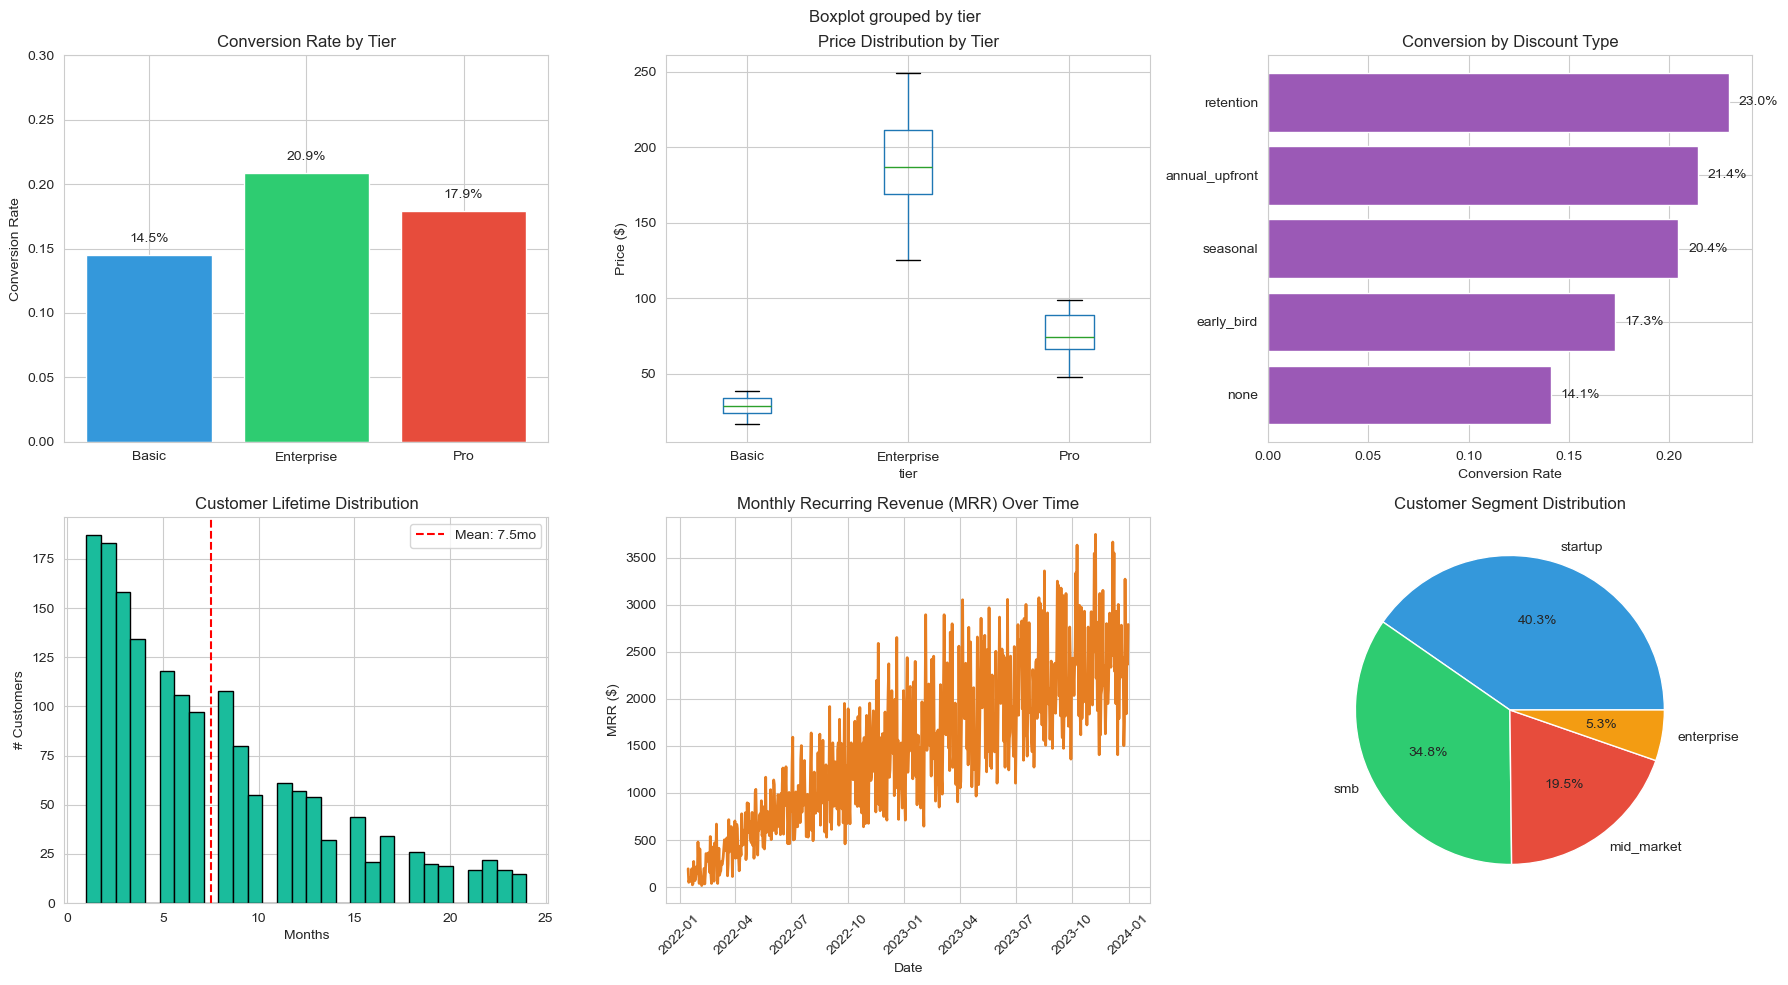

✓ Visualizations generated


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SaaS Pricing Data - Overview', fontsize=16, fontweight='bold')

# 1. Conversion by Tier
conv_by_tier = df_customers.groupby('tier')['converted'].mean()
axes[0, 0].bar(conv_by_tier.index, conv_by_tier.values, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Conversion Rate by Tier')
axes[0, 0].set_ylabel('Conversion Rate')
axes[0, 0].set_ylim(0, 0.3)
for i, v in enumerate(conv_by_tier.values):
    axes[0, 0].text(i, v + 0.01, f'{v:.1%}', ha='center')

# 2. Price Distribution
df_customers.boxplot(column='final_price', by='tier', ax=axes[0, 1])
axes[0, 1].set_title('Price Distribution by Tier')
axes[0, 1].set_ylabel('Price ($)')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# 3. Discount Impact on Conversion
discount_conv = df_customers.groupby('discount_type')['converted'].mean().sort_values()
axes[0, 2].barh(discount_conv.index, discount_conv.values, color='#9b59b6')
axes[0, 2].set_title('Conversion by Discount Type')
axes[0, 2].set_xlabel('Conversion Rate')
for i, v in enumerate(discount_conv.values):
    axes[0, 2].text(v + 0.005, i, f'{v:.1%}', va='center')

# 4. Customer Lifetime Distribution
lifetime = df_subscriptions.groupby('customer_id')['tenure_months'].max()
axes[1, 0].hist(lifetime, bins=30, color='#1abc9c', edgecolor='black')
axes[1, 0].set_title('Customer Lifetime Distribution')
axes[1, 0].set_xlabel('Months')
axes[1, 0].set_ylabel('# Customers')
axes[1, 0].axvline(lifetime.mean(), color='red', linestyle='--', label=f'Mean: {lifetime.mean():.1f}mo')
axes[1, 0].legend()

# 5. MRR Over Time
mrr_over_time = df_subscriptions.groupby('event_date')['monthly_revenue'].sum().reset_index()
axes[1, 1].plot(mrr_over_time['event_date'], mrr_over_time['monthly_revenue'], color='#e67e22', linewidth=2)
axes[1, 1].set_title('Monthly Recurring Revenue (MRR) Over Time')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('MRR ($)')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Segment Distribution
segment_dist = df_customers['segment'].value_counts()
axes[1, 2].pie(segment_dist.values, labels=segment_dist.index, autopct='%1.1f%%', colors=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
axes[1, 2].set_title('Customer Segment Distribution')

plt.tight_layout()
plt.show()

print("✓ Visualizations generated")

## 6. Save Data to Files

In [7]:
# Create data directory if it doesn't exist
import os
os.makedirs('../data', exist_ok=True)

# Save customer data
df_customers.to_csv('../data/saas_customers.csv', index=False)
print(f"✓ Saved customer data: {len(df_customers):,} rows")

# Save subscription history
df_subscriptions.to_csv('../data/saas_subscriptions.csv', index=False)
print(f"✓ Saved subscription data: {len(df_subscriptions):,} rows")

# Save summary statistics
summary_stats = {
    'total_customers': len(df_customers),
    'converted_customers': df_customers['converted'].sum(),
    'conversion_rate': df_customers['converted'].mean(),
    'avg_price': df_customers['final_price'].mean(),
    'total_subscription_months': len(df_subscriptions),
    'avg_customer_lifetime_months': df_subscriptions.groupby('customer_id')['tenure_months'].max().mean(),
    'churn_rate': df_subscriptions['churned'].mean(),
    'total_mrr': df_subscriptions['monthly_revenue'].sum()
}

summary_df = pd.DataFrame([summary_stats])
summary_df.to_csv('../data/summary_statistics.csv', index=False)
print("✓ Saved summary statistics")

print("\n" + "="*60)
print("DATA GENERATION COMPLETE!")
print("="*60)
print("\nFiles created:")
print("  📁 ../data/saas_customers.csv")
print("  📁 ../data/saas_subscriptions.csv")
print("  📁 ../data/summary_statistics.csv")
print("\nNext step: Open 02_multi_armed_bandit.ipynb")

✓ Saved customer data: 10,000 rows
✓ Saved subscription data: 12,501 rows
✓ Saved summary statistics

DATA GENERATION COMPLETE!

Files created:
  📁 ../data/saas_customers.csv
  📁 ../data/saas_subscriptions.csv
  📁 ../data/summary_statistics.csv

Next step: Open 02_multi_armed_bandit.ipynb
